# Введение #

До сих пор в этом курсе мы изучали, как нейронные сети решают задачи регрессии. Теперь мы применим нейронные сети к ещё одной распространённой задаче машинного обучения: классификации. Почти всё, что мы узнали до сих пор, остаётся в силе. Основное отличие заключается в функции потерь, которую мы используем, и в том, какие выходные значения мы хотим получить от последнего слоя.

# Бинарная классификация #

Классификация на один из двух классов — это распространённая задача машинного обучения. Вы можете захотеть предсказать, совершит ли клиент покупку, была ли транзакция по кредитной карте мошеннической, указывают ли сигналы из глубокого космоса на существование новой планеты или результаты медицинского теста — на наличие заболевания. Всё это задачи **бинарной классификации**.

В исходных данных классы могут быть представлены строками, такими как `"Yes"` и `"No"`, или `"Dog"` и `"Cat"`. Перед использованием этих данных мы назначим **метку класса**: один класс будет `0`, а другой — `1`. Присвоение числовых меток приводит данные к форме, которую может использовать нейронная сеть.

# Точность и кросс-энтропия #

**Точность (accuracy)** — один из многих показателей, используемых для оценки успешности решения задачи классификации. Точность — это отношение правильных предсказаний к общему количеству предсказаний: `accuracy = number_correct / total`. Модель, которая всегда предсказывает правильно, получит показатель точности `1.0`. При прочих равных, точность является разумным показателем, когда классы в наборе данных встречаются примерно с одинаковой частотой.

Проблема с точностью (и большинством других показателей классификации) заключается в том, что её нельзя использовать в качестве функции потерь. SGD (стохастическому градиентному спуску) нужна функция потерь, которая изменяется плавно, но точность, будучи отношением количеств, изменяется «скачками». Поэтому мы должны выбрать замену, которая будет действовать как функция потерь. Этой заменой является функция *кросс-энтропии*.

Напомним, что функция потерь определяет *цель* сети во время обучения. В регрессии нашей целью было минимизировать расстояние между ожидаемым результатом и предсказанным результатом. Мы выбрали MAE (среднюю абсолютную ошибку) для измерения этого расстояния.

Для классификации нам нужно расстояние между *вероятностями*, и именно это обеспечивает кросс-энтропия. **Кросс-энтропия** — это своего рода мера расстояния от одного распределения вероятностей до другого.

<figure style="padding: 1em;">

<img src="https://storage.googleapis.com/kaggle-media/learn/images/DwVV9bR.png" width="400" alt="Графики точности и кросс-энтропии.">

<figcaption style="textalign: center; font-style: italic"><center>Кросс-энтропия штрафует за неверные предсказания вероятностей.</center></figcaption>

</figure>

Идея в том, что мы хотим, чтобы наша сеть предсказывала правильный класс с вероятностью `1.0`. Чем дальше предсказанная вероятность от `1.0`, тем больше будет потеря кросс-энтропии.

Технические причины использования кросс-энтропии несколько тонки, но главный вывод из этого раздела таков: используйте кросс-энтропию в качестве функции потерь для классификации; другие показатели, которые могут вас интересовать (например, точность), будут улучшаться вместе с ней.

# Получение вероятностей с помощью сигмоидной функции #

Функции кросс-энтропии и точности требуют на вход вероятности, то есть числа от 0 до 1. Чтобы преобразовать вещественные выходные значения, полученные от полносвязного слоя, в вероятности, мы добавляем новый тип функции активации — **сигмоидную активацию**.

<figure style="padding: 1em;">

<img src="https://storage.googleapis.com/kaggle-media/learn/images/FYbRvJo.png" width="400" alt="График сигмоиды имеет S-образную форму с горизонтальными асимптотами на уровне 0 слева и 1 справа.">

<figcaption style="textalign: center; font-style: italic"><center>Сигмоидная функция отображает вещественные числа в интервал $[0, 1]$.</center></figcaption>

</figure>

Чтобы получить окончательный предсказанный класс, мы определяем *пороговую* вероятность. Обычно это 0.5, так что округление даст нам правильный класс: ниже 0.5 означает класс с меткой 0, а 0.5 и выше — класс с меткой 1. Порог 0.5 используется Keras по умолчанию в его [метрике точности](https://www.tensorflow.org/api_docs/python/tf/keras/metrics/BinaryAccuracy).

# Пример — Бинарная классификация #

А теперь попробуем!

Набор данных [Ionosphere](https://archive.ics.uci.edu/ml/datasets/Ionosphere) содержит признаки, полученные из радиолокационных сигналов, направленных на ионосферный слой атмосферы Земли. Задача состоит в том, чтобы определить, указывает ли сигнал на наличие какого-либо объекта или это просто пустое пространство.

In [2]:
import pandas as pd
from IPython.display import display

ion = pd.read_csv('./data/ion.csv', index_col=0)
display(ion.head())

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V26,V27,V28,V29,V30,V31,V32,V33,V34,Class
1,1,0,0.99539,-0.05889,0.85243,0.02306,0.83398,-0.37708,1.00000,0.03760,...,-0.51171,0.41078,-0.46168,0.21266,-0.34090,0.42267,-0.54487,0.18641,-0.45300,good
2,1,0,1.00000,-0.18829,0.93035,-0.36156,-0.10868,-0.93597,1.00000,-0.04549,...,-0.26569,-0.20468,-0.18401,-0.19040,-0.11593,-0.16626,-0.06288,-0.13738,-0.02447,bad
3,1,0,1.00000,-0.03365,1.00000,0.00485,1.00000,-0.12062,0.88965,0.01198,...,-0.40220,0.58984,-0.22145,0.43100,-0.17365,0.60436,-0.24180,0.56045,-0.38238,good
4,1,0,1.00000,-0.45161,1.00000,1.00000,0.71216,-1.00000,0.00000,0.00000,...,0.90695,0.51613,1.00000,1.00000,-0.20099,0.25682,1.00000,-0.32382,1.00000,bad
5,1,0,1.00000,-0.02401,0.94140,0.06531,0.92106,-0.23255,0.77152,-0.16399,...,-0.65158,0.13290,-0.53206,0.02431,-0.62197,-0.05707,-0.59573,-0.04608,-0.65697,good


In [3]:
df = ion.copy()
df['Class'] = df['Class'].map({'good': 0, 'bad': 1})

df_train = df.sample(frac=0.7, random_state=0)
df_valid = df.drop(df_train.index)

max_ = df_train.max(axis=0)
min_ = df_train.min(axis=0)

df_train = (df_train - min_) / (max_ - min_)
df_valid = (df_valid - min_) / (max_ - min_)
df_train.dropna(axis=1, inplace=True) # удаляем пустой признак во 2-м столбце
df_valid.dropna(axis=1, inplace=True)

X_train = df_train.drop('Class', axis=1)
X_valid = df_valid.drop('Class', axis=1)
y_train = df_train['Class']
y_valid = df_valid['Class']

Мы определим нашу модель так же, как и для задач регрессии, за одним исключением. В последнем слое мы укажем активацию `'sigmoid'`, чтобы модель выдавала вероятности классов.

In [4]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(4, activation='relu', input_shape=[33]),
    layers.Dense(4, activation='relu'),    
    layers.Dense(1, activation='sigmoid'),
])

c:\Users\iOlvik\Documents\1_Dev\Work\ML_training\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Добавим кросс-энтропийную функцию потерь и метрику точности в модель с помощью метода `compile`. Для задач с двумя классами обязательно используйте версии с префиксом `'binary'`. (Задачи с бóльшим количеством классов будут немного отличаться.) Оптимизатор Adam отлично работает и для классификации, так что мы его и оставим.

In [5]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['binary_accuracy'],
)

Модели в этой конкретной задаче может потребоваться довольно много эпох для завершения обучения, поэтому для удобства мы добавим коллбэк ранней остановки.

In [6]:
early_stopping = keras.callbacks.EarlyStopping(
    patience=10,
    min_delta=0.001,
    restore_best_weights=True,
)

In [7]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    batch_size=512,
    epochs=1000,
    callbacks=[early_stopping],
    verbose=0, # скрываем вывод, так как у нас много эпох
)

Мы, как всегда, посмотрим на кривые обучения, а также проверим наилучшие значения потерь и точности, полученные на валидационном наборе. (Напомним, что ранняя остановка восстановит веса, соответствующие этим значениям.)

Best Validation Loss: 0.2506
Best Validation Accuracy: 0.9048


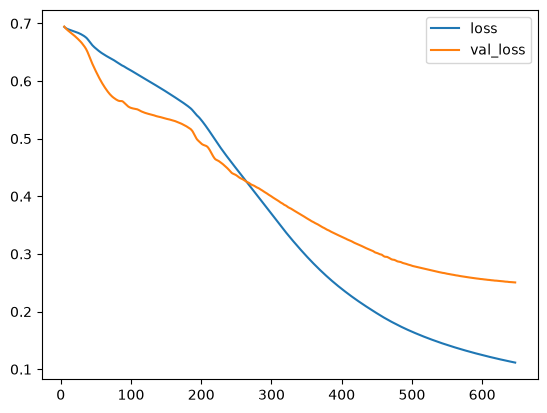

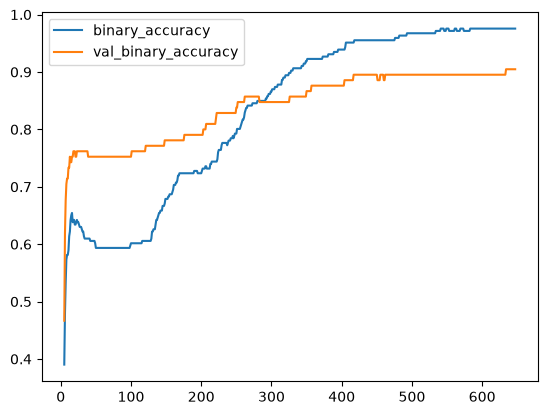

In [8]:
history_df = pd.DataFrame(history.history)

# Начинаем график с 5-й эпохи
history_df.loc[5:, ['loss', 'val_loss']].plot()
history_df.loc[5:, ['binary_accuracy', 'val_binary_accuracy']].plot()

print(("Best Validation Loss: {:0.4f}" +\
      "\nBest Validation Accuracy: {:0.4f}")\
      .format(history_df['val_loss'].min(), 
              history_df['val_binary_accuracy'].max()))

# Ваша очередь #

Используйте нейронную сеть, чтобы [**предсказать отмены бронирований в отелях**](https://www.kaggle.com/kernels/fork/11887335) с помощью набора данных *Hotel Cancellations*.

---

*Есть вопросы или комментарии? Посетите [форум обсуждения курса](https://www.kaggle.com/learn/intro-to-deep-learning/discussion), чтобы пообщаться с другими учащимися.*